# 🧠 Stroke Prediction using Machine Learning

## 📖 Project Description

Stroke is one of the leading causes of death worldwide. Early prediction can help doctors identify high-risk patients and provide preventive treatment.

This project applies multiple Machine Learning algorithms to predict whether a patient is likely to have a stroke based on medical and demographic information.

---

## 🎯 Project Goal

The objective of this project is to:

- Explore and analyze the dataset.
- Clean and preprocess the data.
- Handle missing values and outliers.
- Encode categorical features.
- Handle class imbalance.
- Train multiple machine learning models.
- Tune each model using GridSearchCV.
- Compare model performance.
- Interpret the most important features affecting stroke prediction.
- Build a prediction pipeline for new patients.

---

## 📂 Dataset Features

| Feature | Description |
|----------|-------------|
| id | Patient ID |
| gender | Gender |
| age | Patient Age |
| hypertension | High Blood Pressure |
| heart_disease | Heart Disease |
| ever_married | Married or Not |
| work_type | Employment Type |
| Residence_type | Urban / Rural |
| avg_glucose_level | Average Blood Glucose |
| bmi | Body Mass Index |
| smoking_status | Smoking Status |
| stroke | Target Variable |

In [ ]:
# ==========================
# Data Handling
# ==========================

import numpy as np
import pandas as pd

# ==========================
# Data Visualization
# ==========================

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

sns.set_theme(style="whitegrid")

# ==========================
# Machine Learning
# ==========================

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# ==========================
# Handle Imbalanced Data
# ==========================

from imblearn.over_sampling import SMOTE

# ==========================
# Metrics
# ==========================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# ==========================
# Ignore Warnings
# ==========================

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("/content/healthcare-dataset-stroke-data.csv")

In [ ]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows : 5110
Columns : 12


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,5110.0,36517.829354,21161.721625,67.00,17741.250,36932.000,54682.00,72940.00
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00


In [ ]:
df.describe(include='object').T

,count,unique,top,freq
gender,5110,3,Female,2994
ever_married,5110,2,Yes,3353
work_type,5110,5,Private,2925
Residence_type,5110,2,Urban,2596
smoking_status,5110,4,never smoked,1892


In [ ]:
missing = pd.DataFrame({

    "Missing Values":df.isnull().sum(),

    "Percentage":round(df.isnull().mean()*100,2)

})

missing

,Missing Values,Percentage
id,0,0.00
gender,0,0.00
age,0,0.00
hypertension,0,0.00
heart_disease,0,0.00
ever_married,0,0.00
work_type,0,0.00
Residence_type,0,0.00
avg_glucose_level,0,0.00
bmi,201,3.93


In [ ]:
print("Duplicate Rows :",df.duplicated().sum())

Duplicate Rows : 0


In [ ]:
df.dtypes

,0
id,int64
gender,object
age,float64
hypertension,int64
heart_disease,int64
ever_married,object
work_type,object
Residence_type,object
avg_glucose_level,float64
bmi,float64


In [ ]:
df.drop("id",axis=1,inplace=True)

In [ ]:
df["bmi"] = df["bmi"].fillna(df["bmi"].median())

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                5110 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


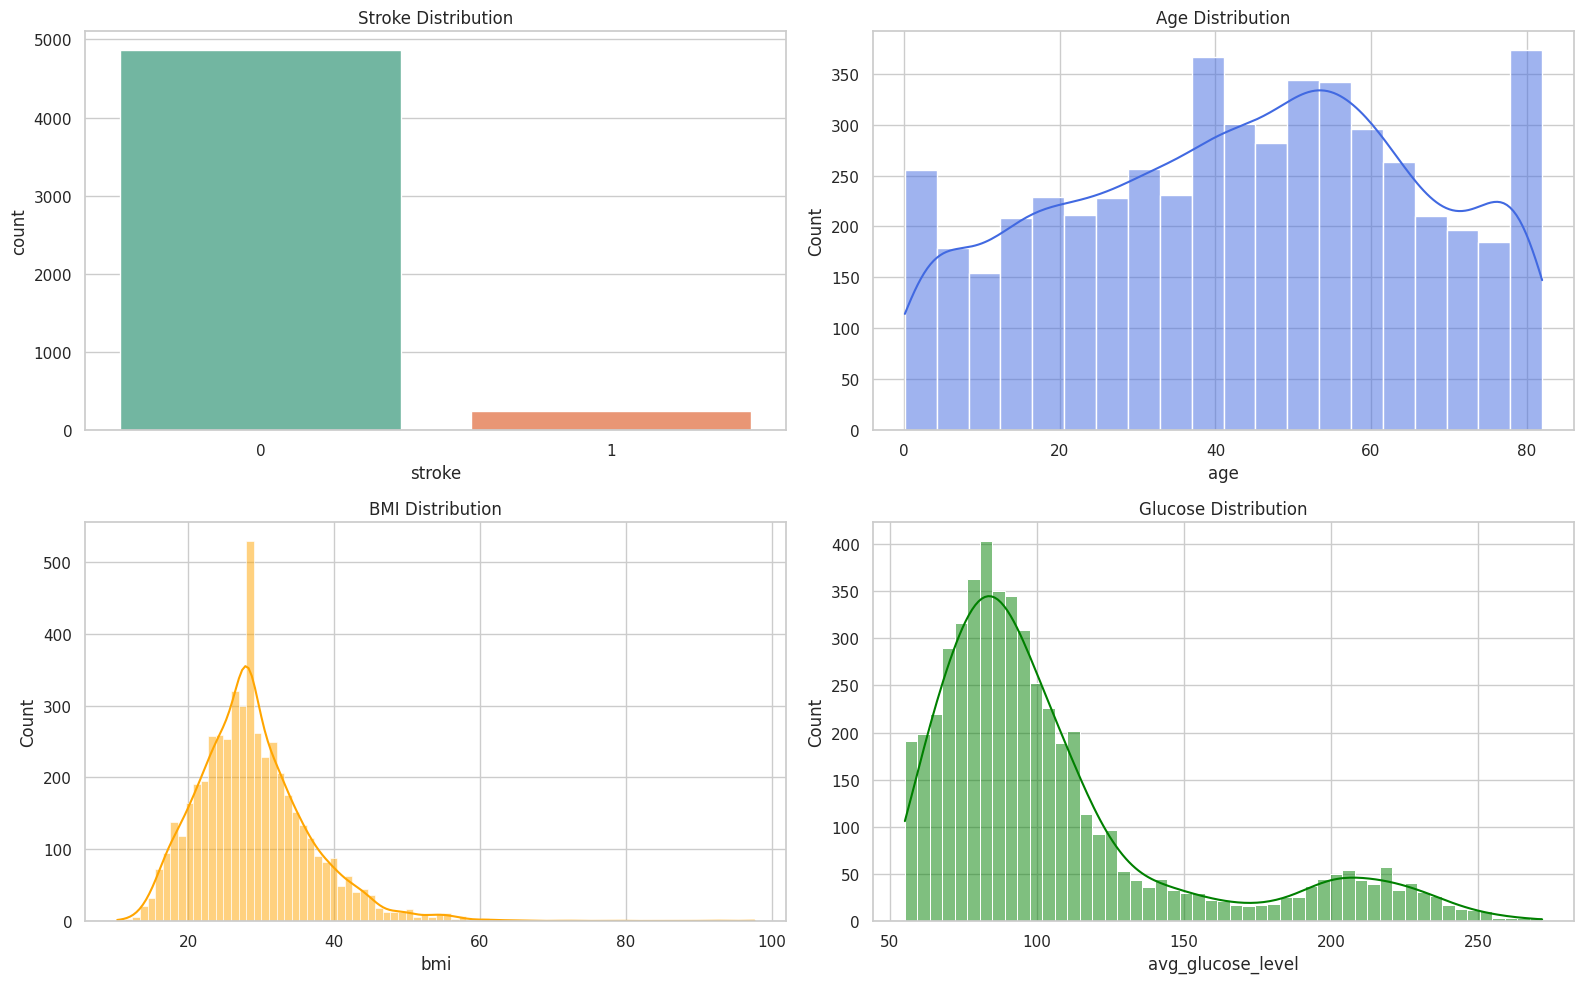

In [ ]:
fig,ax=plt.subplots(2,2,figsize=(16,10))

sns.countplot(
    x='stroke',
    data=df,
    palette='Set2',
    ax=ax[0,0]
)

ax[0,0].set_title("Stroke Distribution")

sns.histplot(
    df['age'],
    kde=True,
    color='royalblue',
    ax=ax[0,1]
)

ax[0,1].set_title("Age Distribution")

sns.histplot(
    df['bmi'],
    kde=True,
    color='orange',
    ax=ax[1,0]
)

ax[1,0].set_title("BMI Distribution")

sns.histplot(
    df['avg_glucose_level'],
    kde=True,
    color='green',
    ax=ax[1,1]
)

ax[1,1].set_title("Glucose Distribution")

plt.tight_layout()

plt.show()

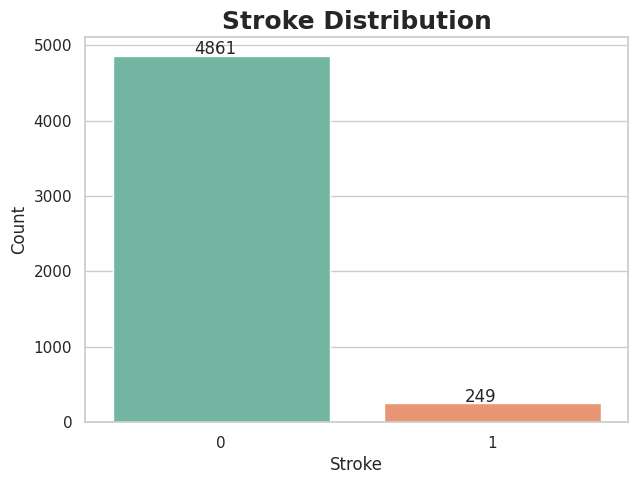

In [ ]:
plt.figure(figsize=(7,5))

ax=sns.countplot(
    x='stroke',
    data=df,
    palette='Set2'
)

plt.title("Stroke Distribution",fontsize=18,fontweight='bold')
plt.xlabel("Stroke")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x()+0.3,p.get_height()+20))

plt.show()

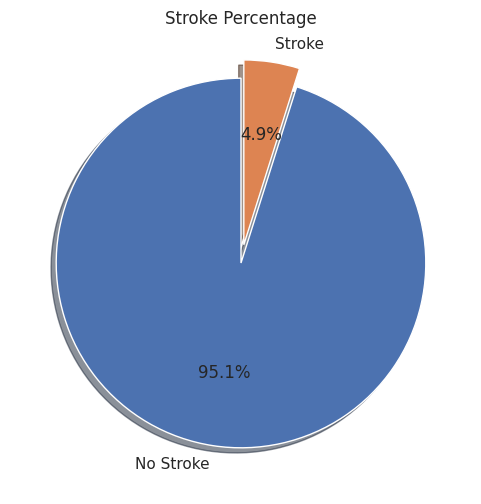

In [ ]:
stroke_percent = df['stroke'].value_counts(normalize=True)*100

plt.figure(figsize=(6,6))

plt.pie(
    stroke_percent,
    labels=['No Stroke','Stroke'],
    autopct='%1.1f%%',
    explode=[0,0.1],
    shadow=True,
    startangle=90
)

plt.title("Stroke Percentage")

plt.show()

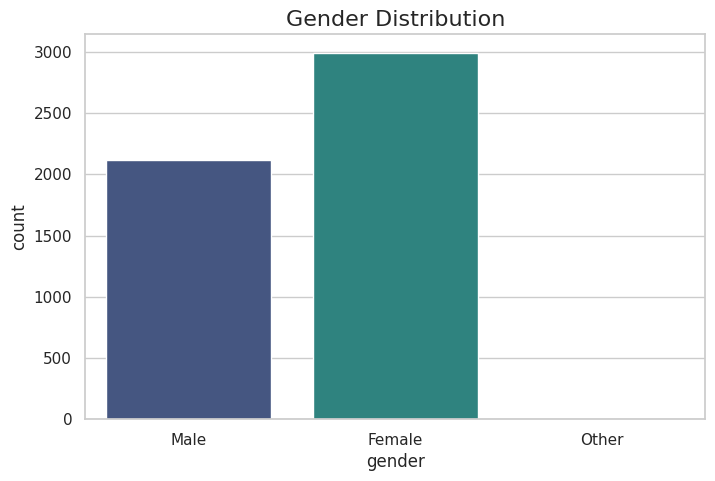

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='gender',
    data=df,
    palette='viridis'
)

plt.title("Gender Distribution",fontsize=16)

plt.show()

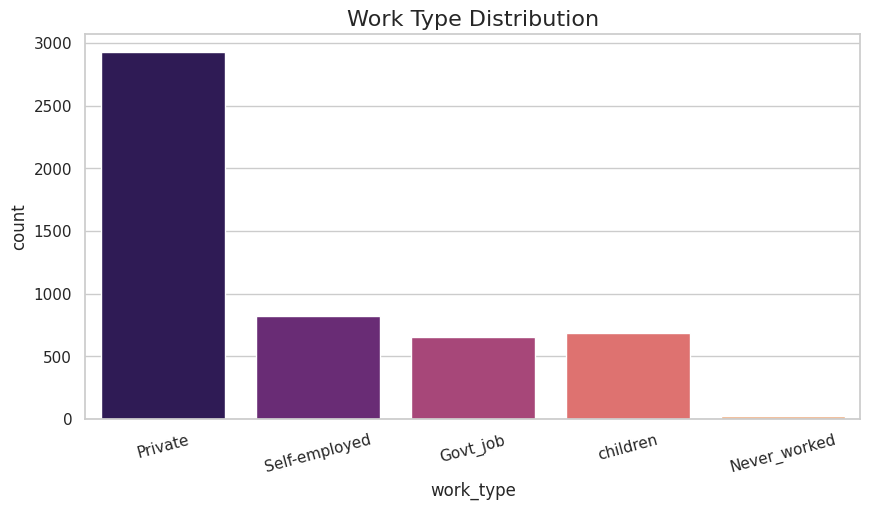

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='work_type',
    data=df,
    palette='magma'
)

plt.title("Work Type Distribution",fontsize=16)

plt.xticks(rotation=15)

plt.show()

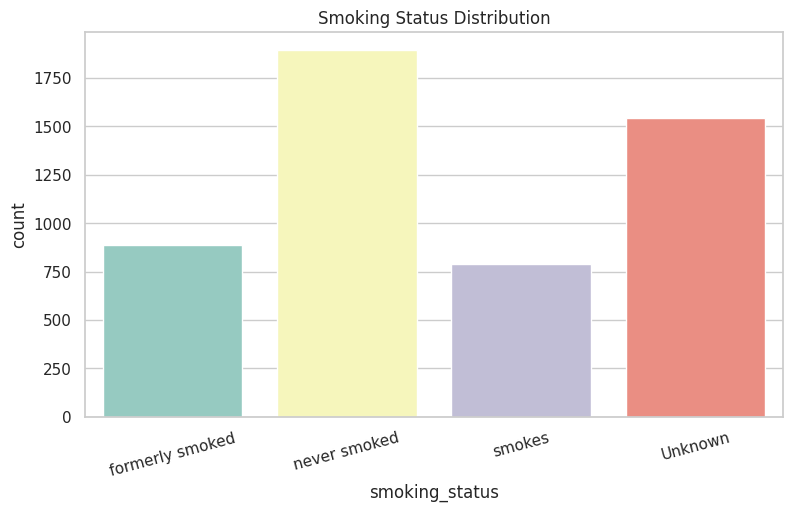

In [ ]:
plt.figure(figsize=(9,5))

sns.countplot(
    x='smoking_status',
    data=df,
    palette='Set3'
)

plt.title("Smoking Status Distribution")

plt.xticks(rotation=15)

plt.show()

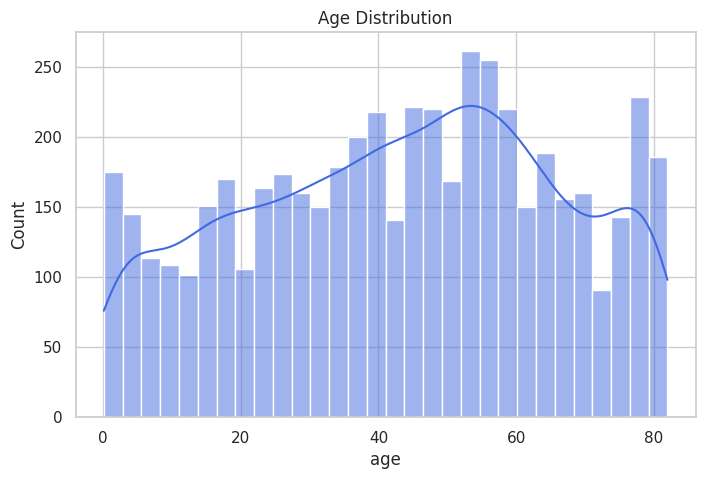

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['age'],
    bins=30,
    kde=True,
    color='royalblue'
)

plt.title("Age Distribution")

plt.show()

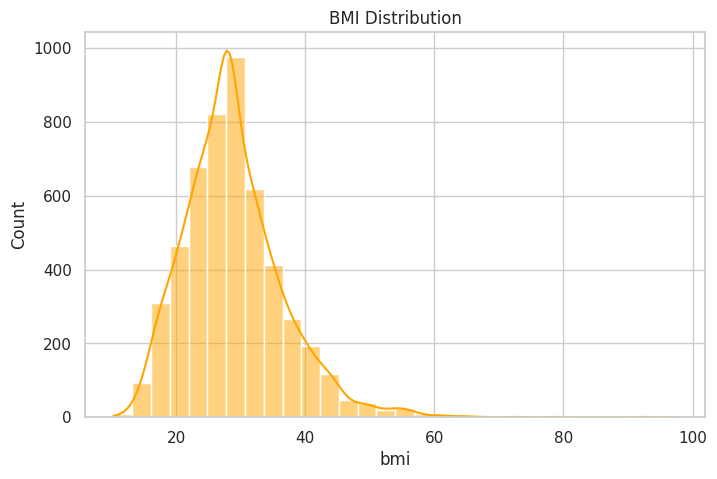

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['bmi'],
    bins=30,
    kde=True,
    color='orange'
)

plt.title("BMI Distribution")

plt.show()

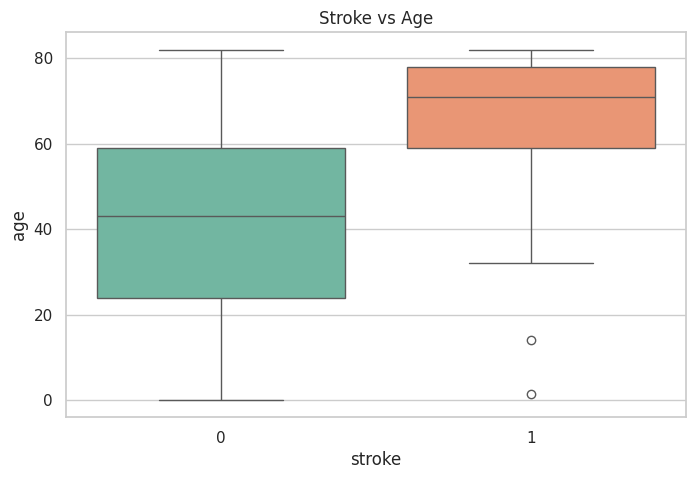

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='stroke',
    y='age',
    data=df,
    palette='Set2'
)

plt.title("Stroke vs Age")

plt.show()

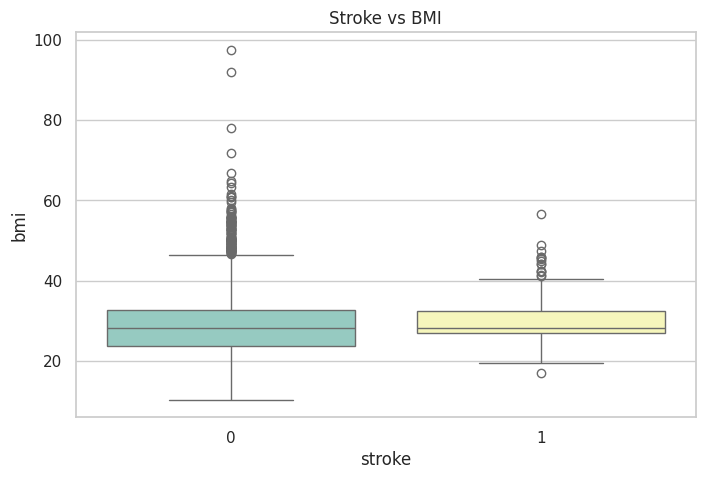

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='stroke',
    y='bmi',
    data=df,
    palette='Set3'
)

plt.title("Stroke vs BMI")

plt.show()

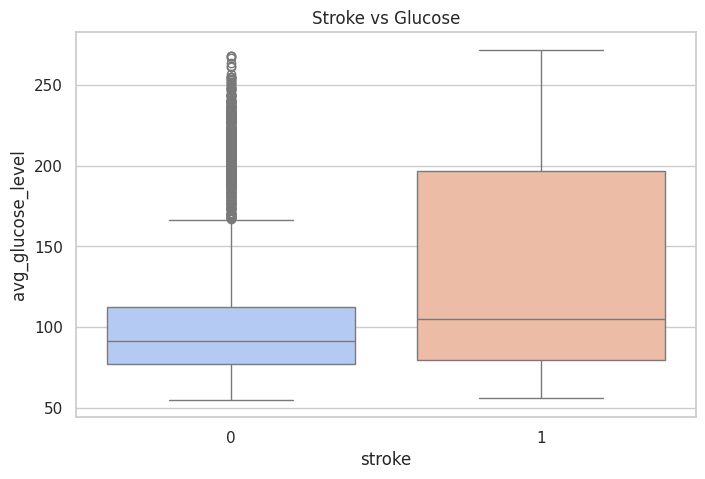

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='stroke',
    y='avg_glucose_level',
    data=df,
    palette='coolwarm'
)

plt.title("Stroke vs Glucose")

plt.show()

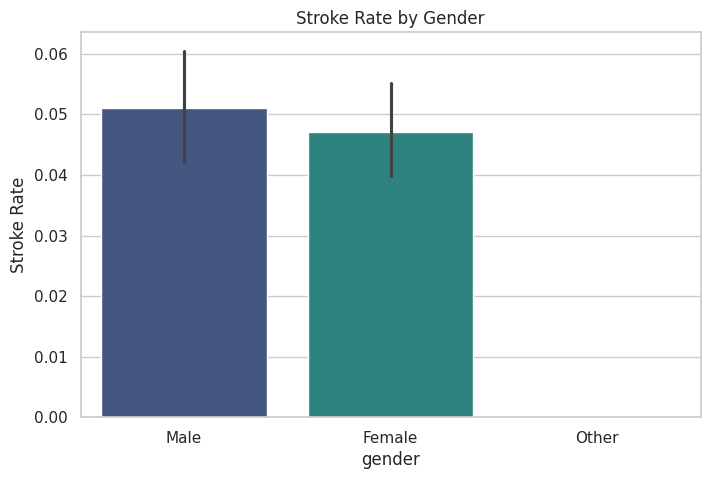

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='gender',
    y='stroke',
    data=df,
    palette='viridis'
)

plt.title("Stroke Rate by Gender")

plt.ylabel("Stroke Rate")

plt.show()

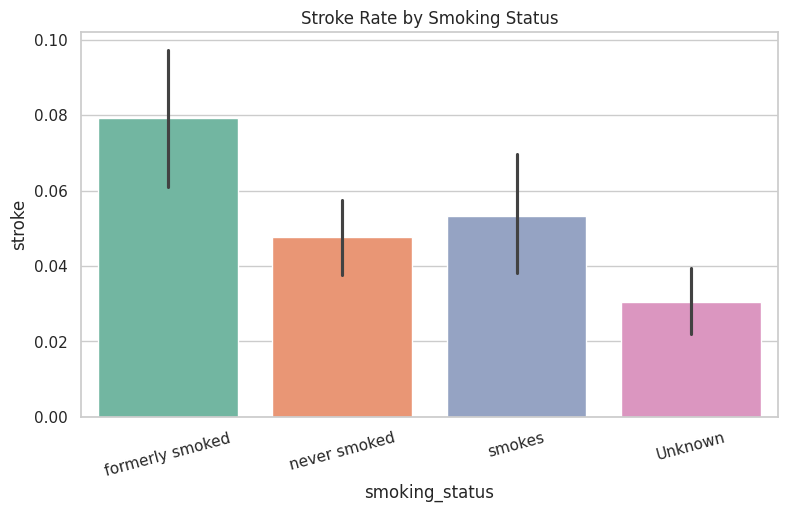

In [ ]:
plt.figure(figsize=(9,5))

sns.barplot(
    x='smoking_status',
    y='stroke',
    data=df,
    palette='Set2'
)

plt.title("Stroke Rate by Smoking Status")

plt.xticks(rotation=15)

plt.show()

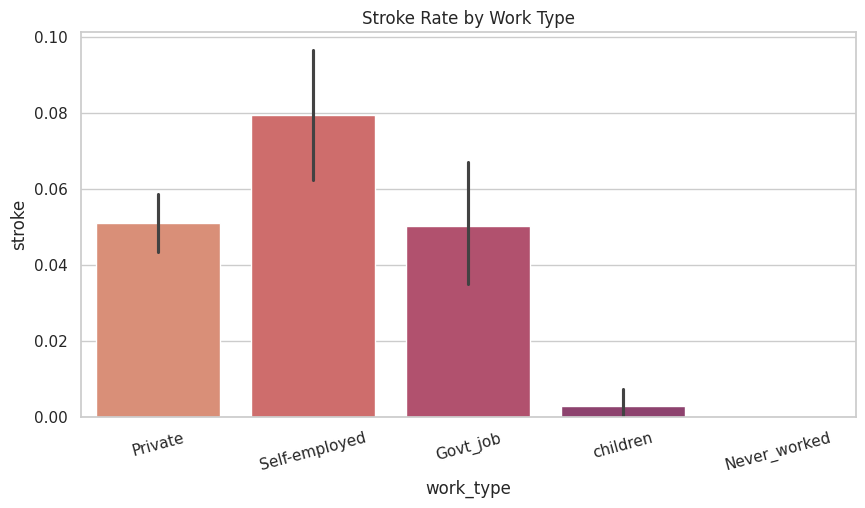

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='work_type',
    y='stroke',
    data=df,
    palette='flare'
)

plt.title("Stroke Rate by Work Type")

plt.xticks(rotation=15)

plt.show()

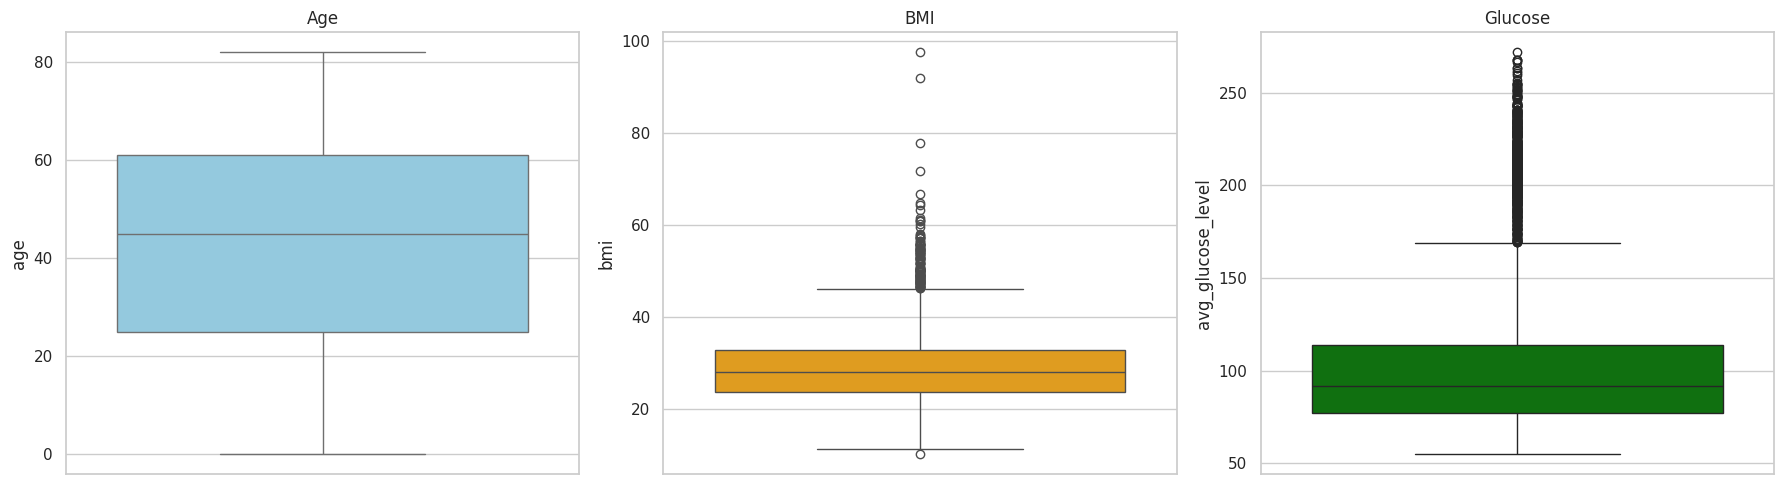

In [ ]:
fig,ax=plt.subplots(1,3,figsize=(18,5))

sns.boxplot(y=df['age'],ax=ax[0],color='skyblue')
ax[0].set_title("Age")

sns.boxplot(y=df['bmi'],ax=ax[1],color='orange')
ax[1].set_title("BMI")

sns.boxplot(y=df['avg_glucose_level'],ax=ax[2],color='green')
ax[2].set_title("Glucose")

plt.tight_layout()

plt.show()

In [ ]:
df_encoded = df.copy()

In [ ]:
df_encoded['ever_married'] = df_encoded['ever_married'].map({
    'No':0,
    'Yes':1
})

df_encoded['Residence_type'] = df_encoded['Residence_type'].map({
    'Rural':0,
    'Urban':1
})

In [ ]:
df_encoded = pd.get_dummies(

    df_encoded,

    columns=[
        'gender',
        'work_type',
        'smoking_status'
    ],

    drop_first=True,

    dtype=int

)

In [ ]:
df_encoded.head()

,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,1,1,228.69,36.6,1,1,0,0,1,0,0,1,0,0
1,61.0,0,0,1,0,202.21,28.1,1,0,0,0,0,1,0,0,1,0
2,80.0,0,1,1,0,105.92,32.5,1,1,0,0,1,0,0,0,1,0
3,49.0,0,0,1,1,171.23,34.4,1,0,0,0,1,0,0,0,0,1
4,79.0,1,0,1,0,174.12,24.0,1,0,0,0,0,1,0,0,1,0


In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             5110 non-null   float64
 1   hypertension                    5110 non-null   int64  
 2   heart_disease                   5110 non-null   int64  
 3   ever_married                    5110 non-null   int64  
 4   Residence_type                  5110 non-null   int64  
 5   avg_glucose_level               5110 non-null   float64
 6   bmi                             5110 non-null   float64
 7   stroke                          5110 non-null   int64  
 8   gender_Male                     5110 non-null   int64  
 9   gender_Other                    5110 non-null   int64  
 10  work_type_Never_worked          5110 non-null   int64  
 11  work_type_Private               5110 non-null   int64  
 12  work_type_Self-employed         51

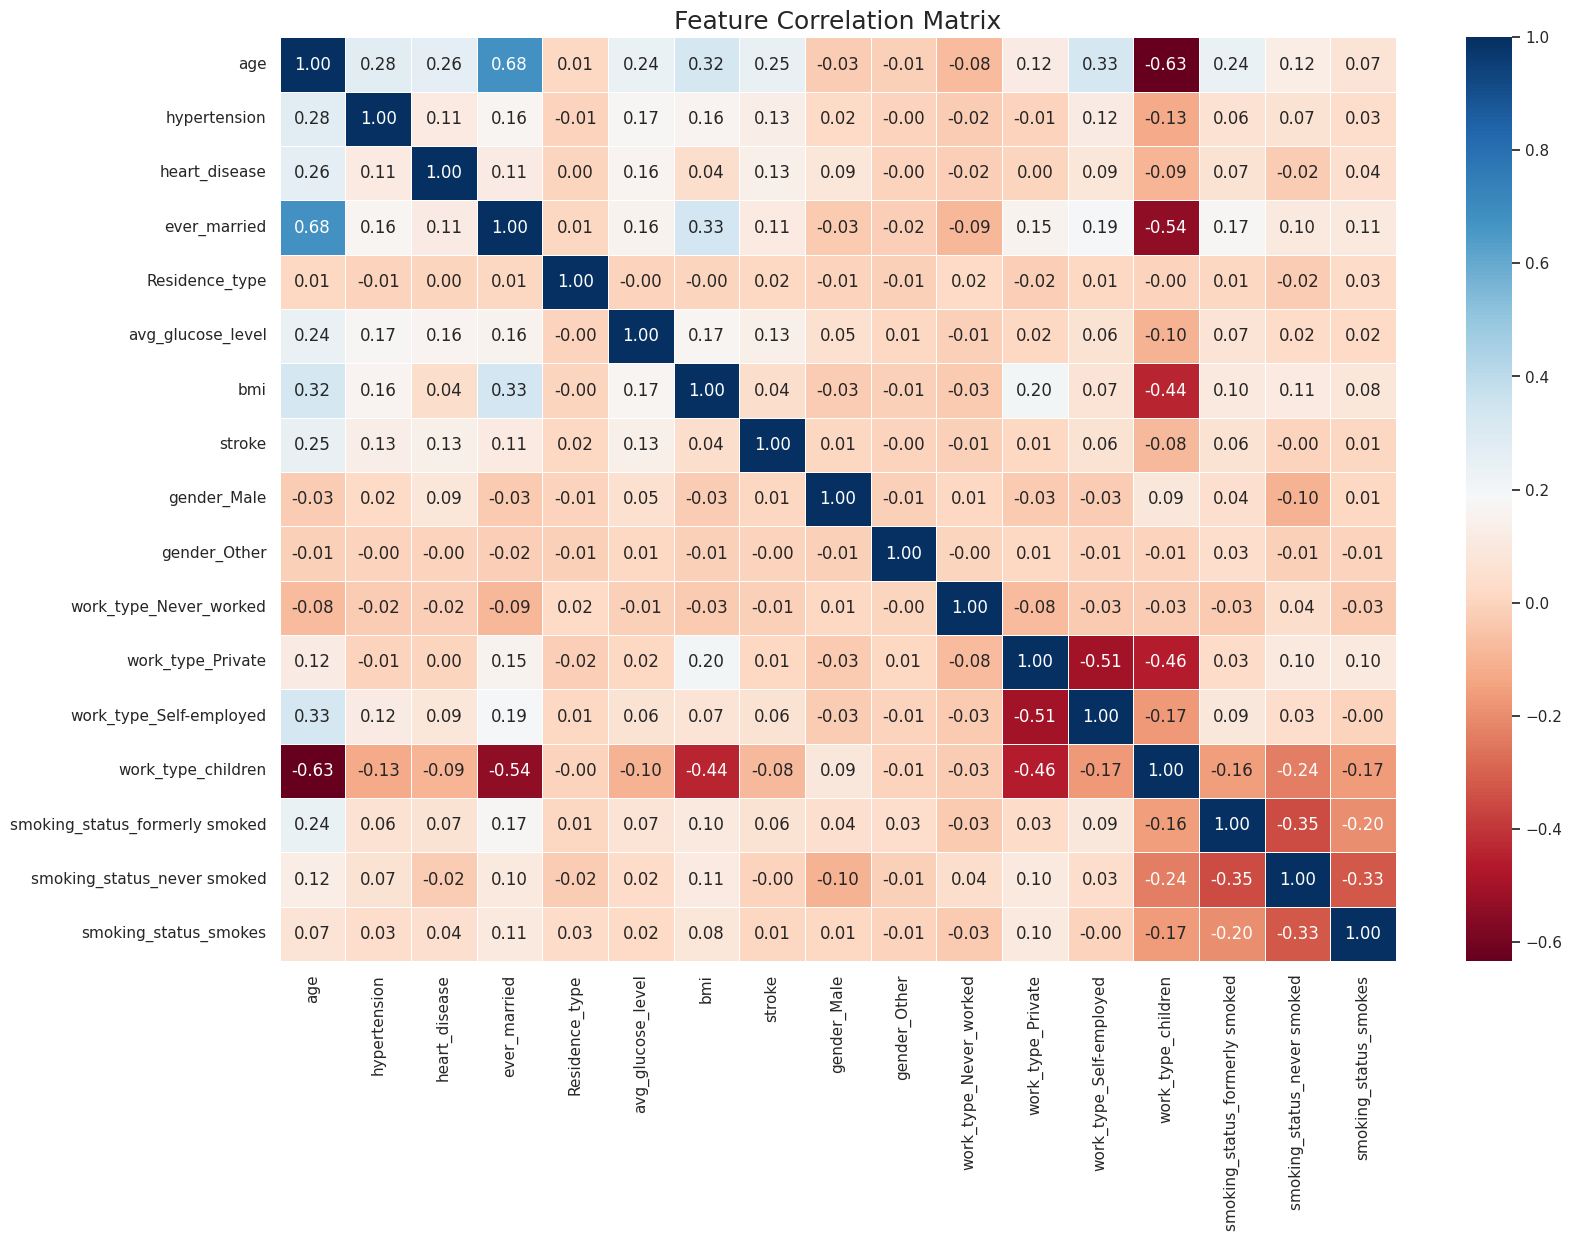

In [ ]:
plt.figure(figsize=(18,12))

sns.heatmap(

    df_encoded.corr(),

    annot=True,

    cmap='RdBu',

    linewidth=.5,

    fmt=".2f"

)

plt.title("Feature Correlation Matrix",fontsize=18)

plt.show()

In [ ]:
X = df_encoded.drop("stroke",axis=1)

y = df_encoded["stroke"]

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [ ]:
from sklearn.base import clone

def evaluate_scaler(model, scaler):

    Xtr = scaler.fit_transform(X_train)

    Xte = scaler.transform(X_test)

    m = clone(model)

    m.fit(Xtr,y_train)

    pred = m.predict(Xte)

    return accuracy_score(y_test,pred)

In [ ]:
standard_acc = evaluate_scaler(

    LogisticRegression(max_iter=1000),

    StandardScaler()

)

In [ ]:
robust_acc = evaluate_scaler(

    LogisticRegression(max_iter=1000),

    RobustScaler()

)

In [ ]:
compare_scaler = pd.DataFrame({

    "Scaler":[

        "Standard",

        "Robust"

    ],

    "Accuracy":[

        standard_acc,

        robust_acc

    ]

})

compare_scaler

,Scaler,Accuracy
0,Standard,0.952055
1,Robust,0.952055


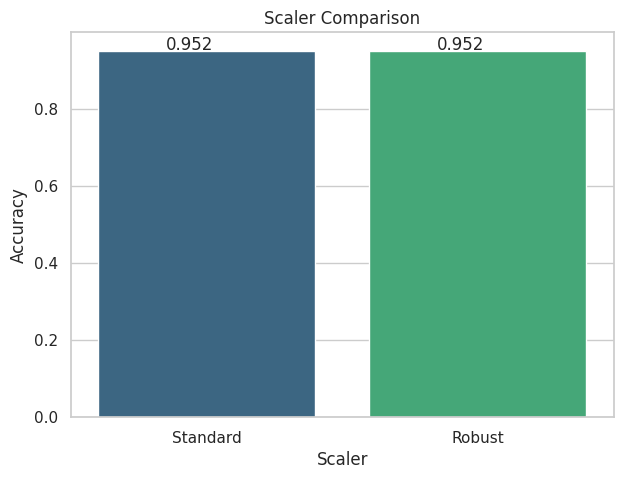

In [ ]:
plt.figure(figsize=(7,5))

ax=sns.barplot(

    data=compare_scaler,

    x="Scaler",

    y="Accuracy",

    palette="viridis"

)

plt.title("Scaler Comparison")

for p in ax.patches:

    ax.annotate(

        f"{p.get_height():.3f}",

        (p.get_x()+0.25,p.get_height()+0.002)

    )

plt.show()

In [ ]:
best_scaler = StandardScaler()

In [ ]:
X_train_scaled = best_scaler.fit_transform(X_train)

X_test_scaled = best_scaler.transform(X_test)

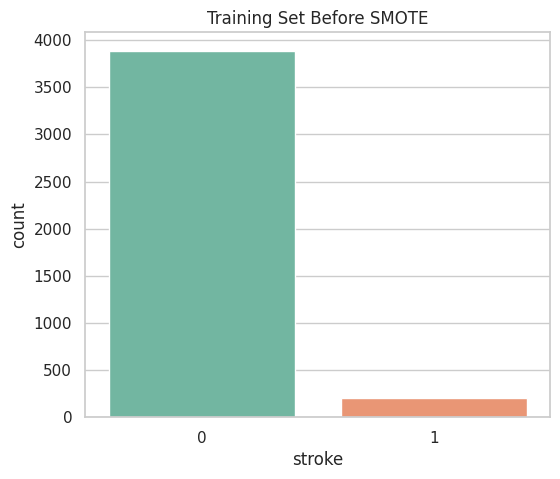

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(x=y_train,palette="Set2")

plt.title("Training Set Before SMOTE")

plt.show()

In [ ]:
y_train.value_counts()

,count
stroke,
0,3889
1,199


In [ ]:
smote = SMOTE(

    random_state=42

)

X_train_smote,y_train_smote = smote.fit_resample(

    X_train_scaled,

    y_train

)

In [ ]:
X_train_smote = pd.DataFrame(
    X_train_smote,
    columns=X_train.columns
)

In [ ]:
X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_train.columns
)

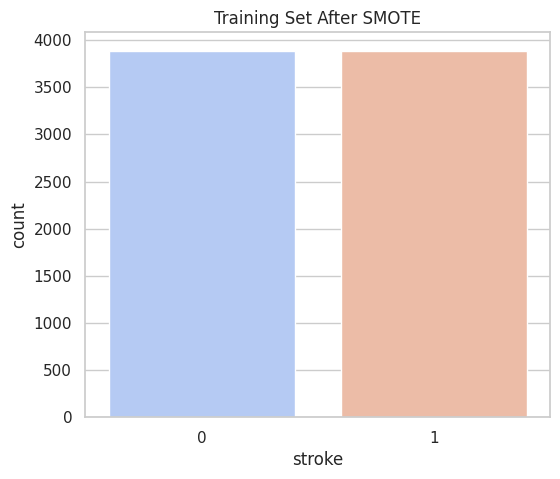

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(

    x=y_train_smote,

    palette="coolwarm"

)

plt.title("Training Set After SMOTE")

plt.show()

In [ ]:
y_train_smote.value_counts()

,count
stroke,
0,3889
1,3889


In [ ]:
from sklearn.base import clone

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [ ]:
results=[]

In [ ]:
def plot_confusion_matrix(cm,title):

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False
    )

    plt.title(title,fontsize=15,fontweight='bold')

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

In [ ]:
from sklearn.metrics import RocCurveDisplay

def plot_roc(model,X_test,y_test,name):

    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test
    )

    plt.title(f"ROC Curve - {name}")

    plt.show()

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

def plot_pr(model,X_test,y_test,name):

    PrecisionRecallDisplay.from_estimator(
        model,
        X_test,
        y_test
    )

    plt.title(f"Precision Recall Curve - {name}")

    plt.show()

In [ ]:
trained_models = {}

def model_evaluate(model, name):

    model = clone(model)

    model.fit(X_train_smote, y_train_smote)

    ...

    trained_models[name] = model

    return model
def model_evaluate(model,name):

    model=clone(model)

    model.fit(X_train_smote,y_train_smote)

    pred=model.predict(X_test_scaled)

    if hasattr(model,"predict_proba"):

        prob=model.predict_proba(X_test_scaled)[:,1]

    else:

        prob=model.decision_function(X_test_scaled)

    acc=accuracy_score(y_test,pred)

    pre=precision_score(y_test,pred)

    rec=recall_score(y_test,pred)

    f1=f1_score(y_test,pred)

    roc=roc_auc_score(y_test,prob)

    print("="*60)

    print(name)

    print("="*60)

    print(classification_report(y_test,pred))

    cm=confusion_matrix(y_test,pred)

    plot_confusion_matrix(cm,name)

    plot_roc(model,X_test_scaled,y_test,name)

    plot_pr(model,X_test_scaled,y_test,name)

    results.append({

        "Model":name,

        "Accuracy":acc,

        "Precision":pre,

        "Recall":rec,

        "F1 Score":f1,

        "ROC AUC":roc

    })
    trained_models[name] = clone(model)

    return model

In [ ]:
from sklearn.linear_model import LogisticRegression, SGDClassifier, PassiveAggressiveClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    BaggingClassifier
)

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
!pip install catboost
from catboost import CatBoostClassifier

Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.75      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.75      0.82      1022



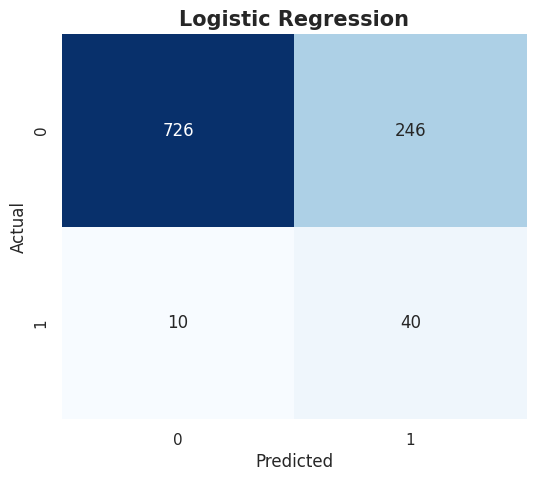

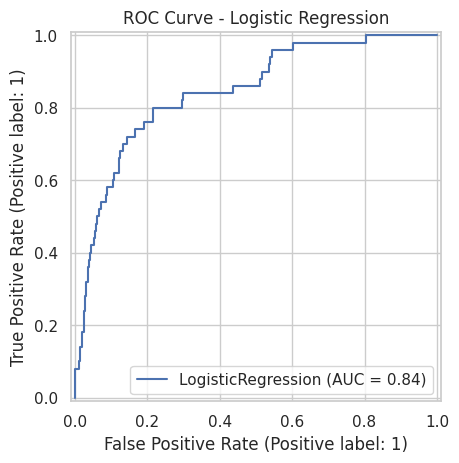

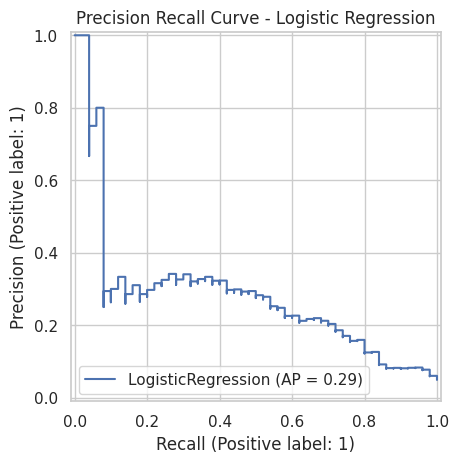

KNN
              precision    recall  f1-score   support

           0       0.96      0.84      0.90       972
           1       0.11      0.40      0.18        50

    accuracy                           0.82      1022
   macro avg       0.54      0.62      0.54      1022
weighted avg       0.92      0.82      0.86      1022



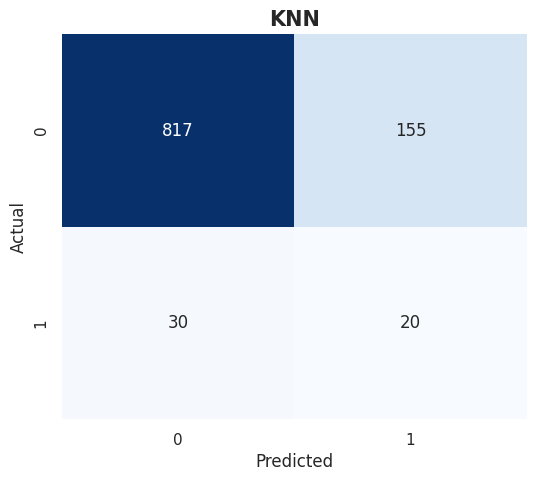

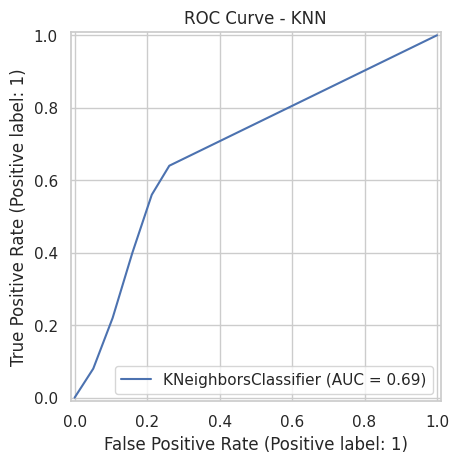

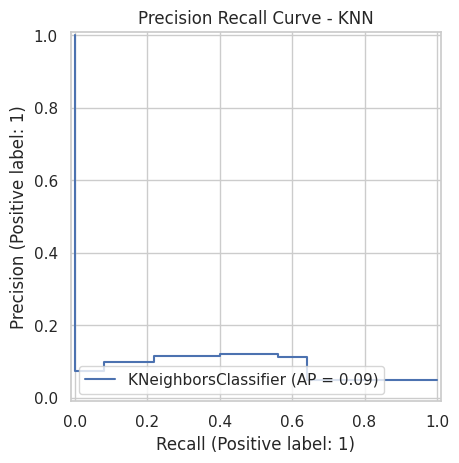

SVM
              precision    recall  f1-score   support

           0       0.97      0.83      0.89       972
           1       0.13      0.50      0.21        50

    accuracy                           0.81      1022
   macro avg       0.55      0.67      0.55      1022
weighted avg       0.93      0.81      0.86      1022



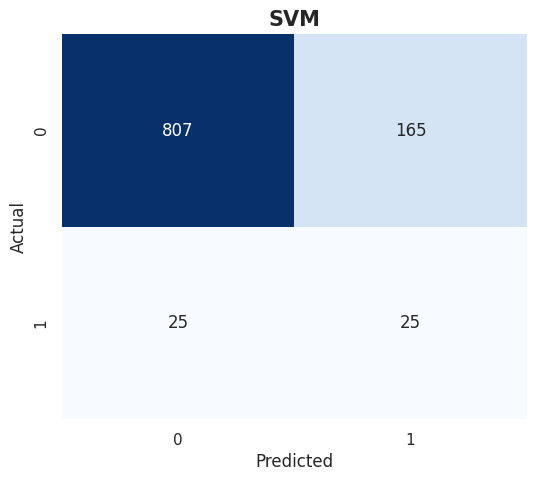

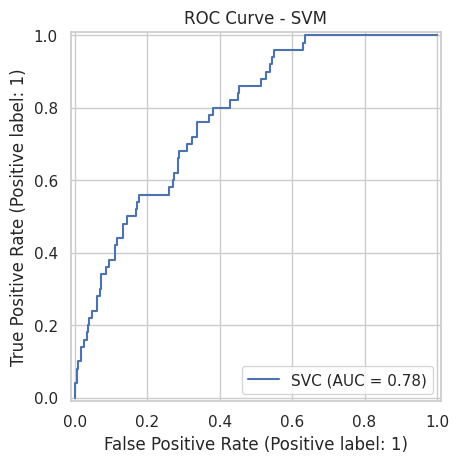

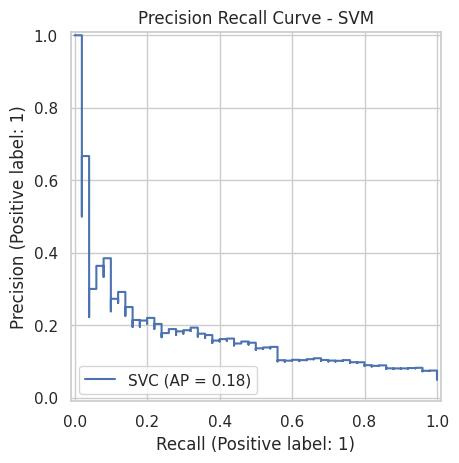

Naive Bayes
              precision    recall  f1-score   support

           0       0.99      0.15      0.25       972
           1       0.06      0.98      0.11        50

    accuracy                           0.19      1022
   macro avg       0.52      0.56      0.18      1022
weighted avg       0.95      0.19      0.25      1022



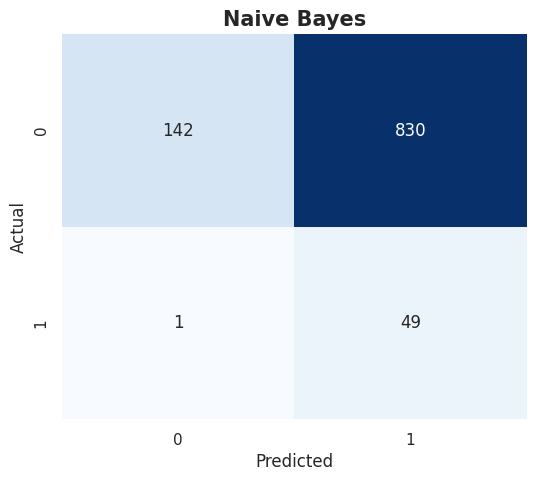

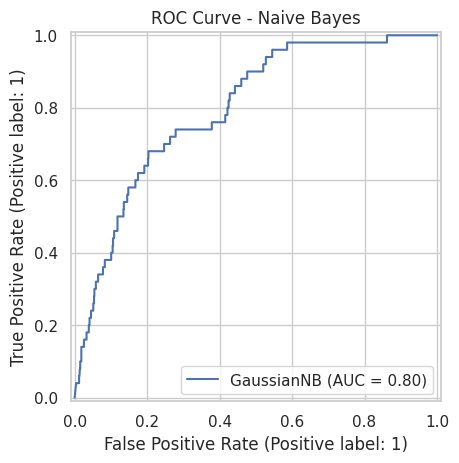

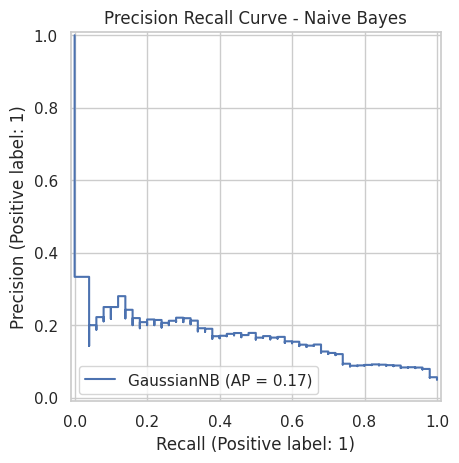

Decision Tree
              precision    recall  f1-score   support

           0       0.96      0.91      0.93       972
           1       0.09      0.18      0.12        50

    accuracy                           0.87      1022
   macro avg       0.52      0.55      0.53      1022
weighted avg       0.91      0.87      0.89      1022



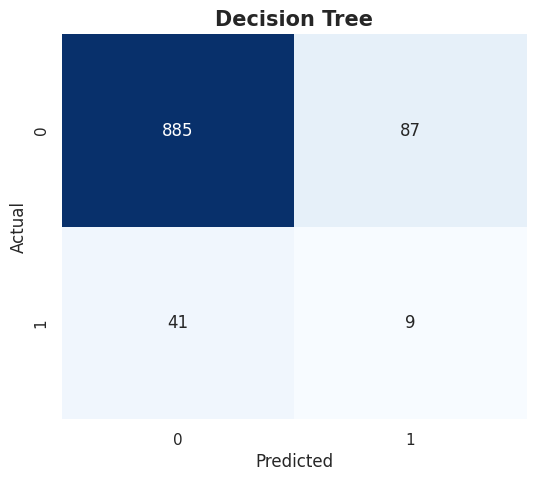

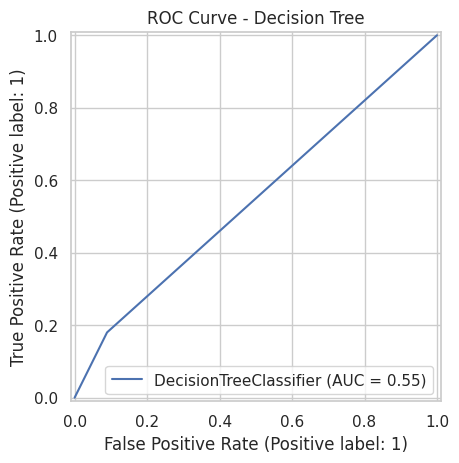

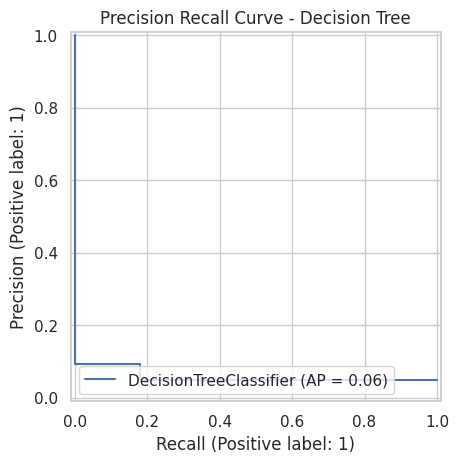

Random Forest
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       972
           1       0.17      0.16      0.16        50

    accuracy                           0.92      1022
   macro avg       0.56      0.56      0.56      1022
weighted avg       0.92      0.92      0.92      1022



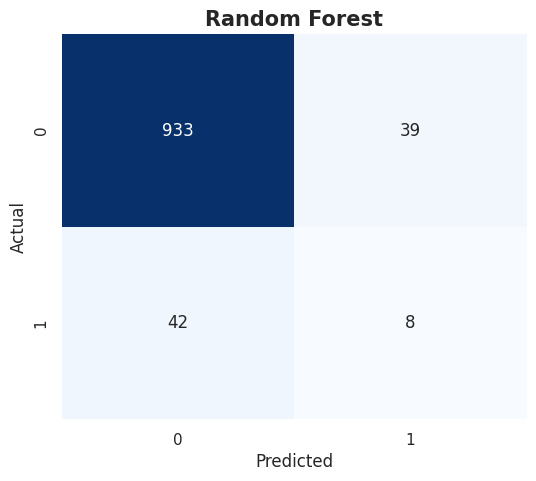

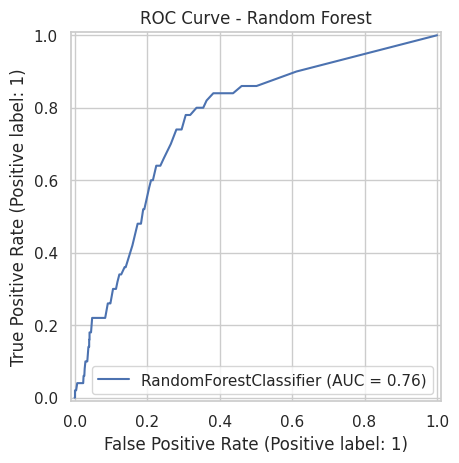

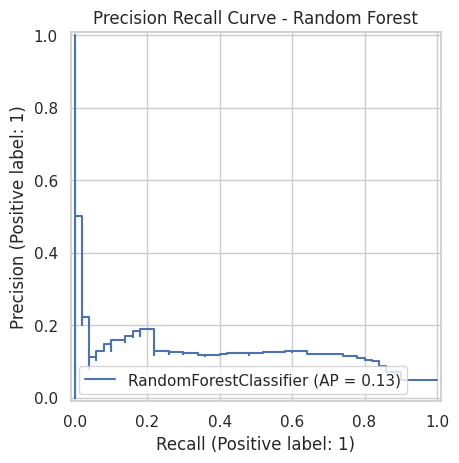

Extra Trees
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       972
           1       0.15      0.14      0.14        50

    accuracy                           0.92      1022
   macro avg       0.55      0.55      0.55      1022
weighted avg       0.92      0.92      0.92      1022



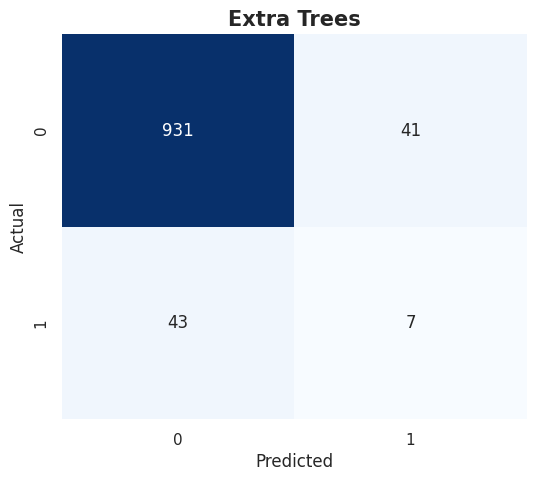

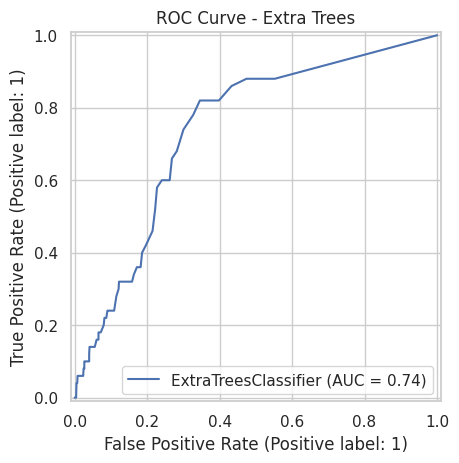

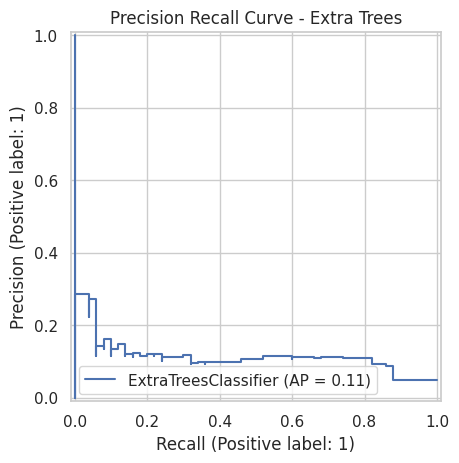

Gradient Boosting
              precision    recall  f1-score   support

           0       0.97      0.88      0.92       972
           1       0.15      0.42      0.22        50

    accuracy                           0.86      1022
   macro avg       0.56      0.65      0.57      1022
weighted avg       0.93      0.86      0.89      1022



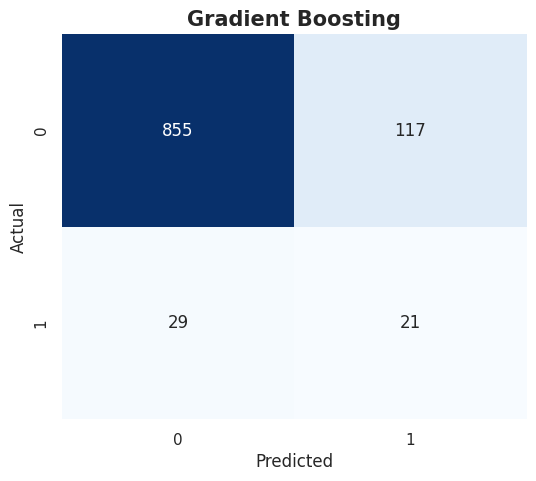

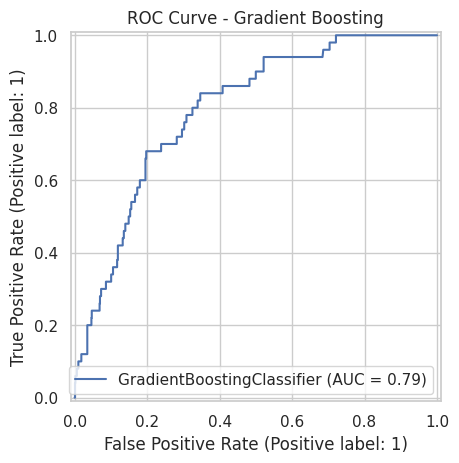

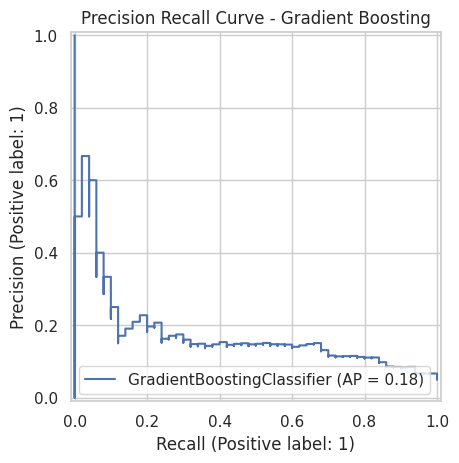

AdaBoost
              precision    recall  f1-score   support

           0       0.99      0.73      0.84       972
           1       0.13      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.81      1022



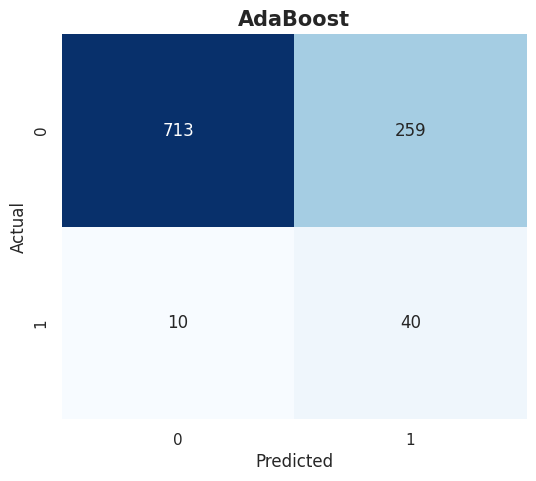

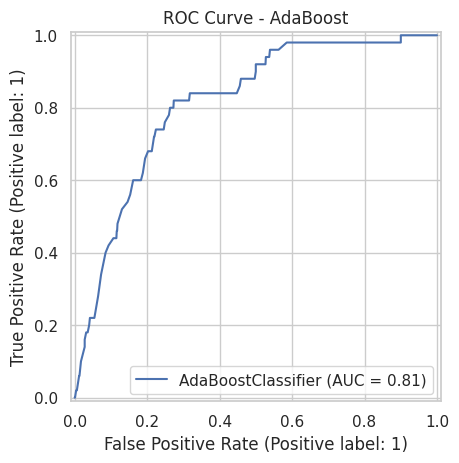

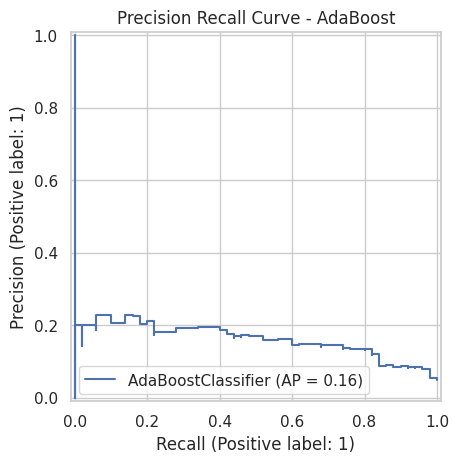

Bagging
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       972
           1       0.14      0.18      0.16        50

    accuracy                           0.91      1022
   macro avg       0.55      0.56      0.55      1022
weighted avg       0.92      0.91      0.91      1022



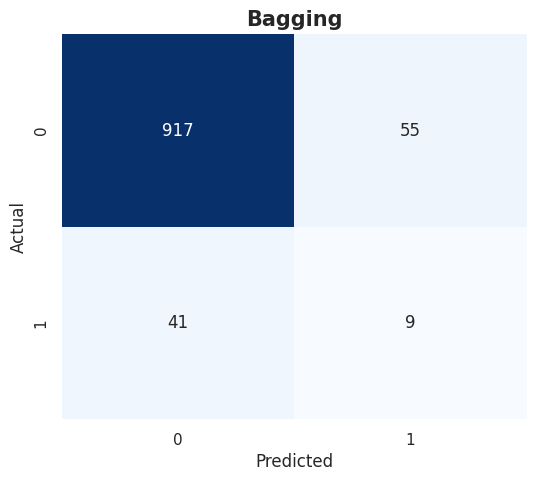

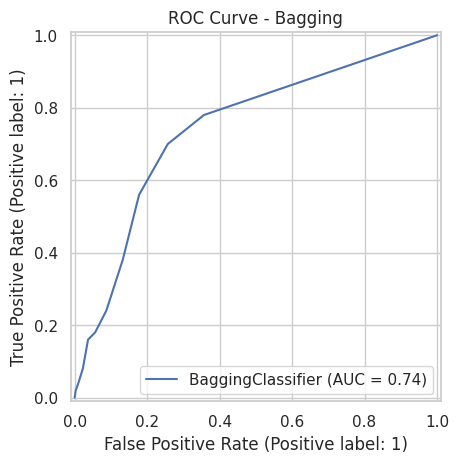

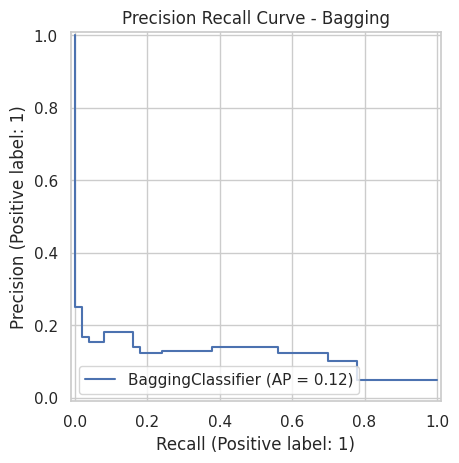

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3889, number of negative: 3889
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003708 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2158
[LightGBM] [Info] Number of data points in the train set: 7778, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       972
           1       0.28      0.16      0.20        50

    accuracy                           0.94      1022
   macro avg       0.62      0.57      0.59      1022
weighted avg       0.92      0.94      0.93      1022



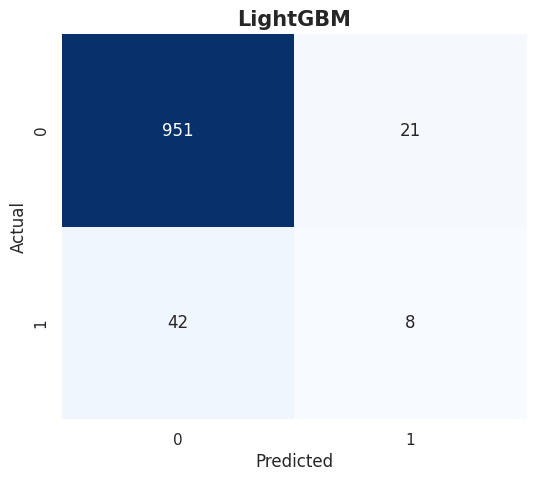

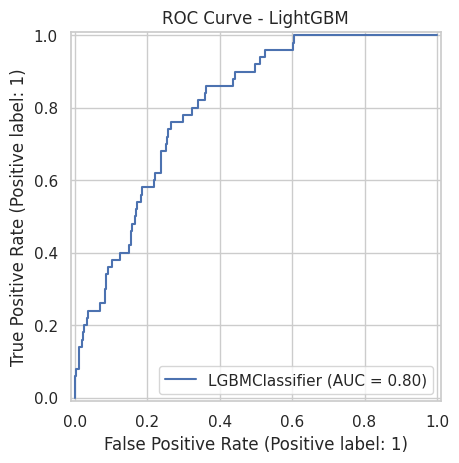

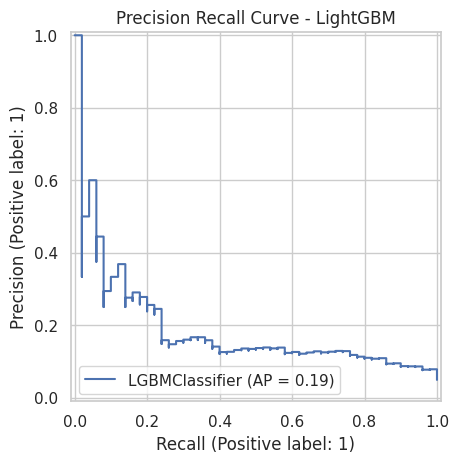

XGBoost
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       972
           1       0.22      0.12      0.16        50

    accuracy                           0.94      1022
   macro avg       0.59      0.55      0.56      1022
weighted avg       0.92      0.94      0.93      1022



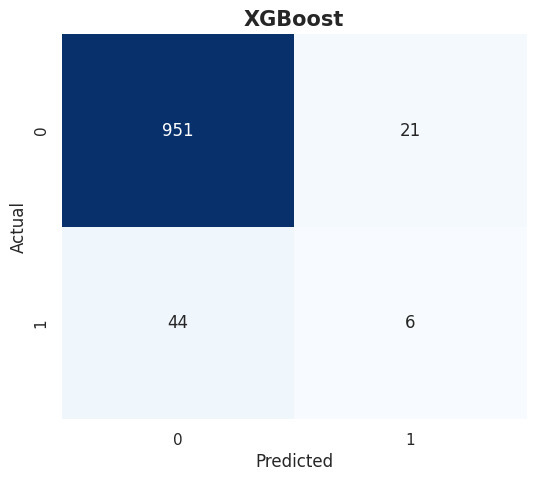

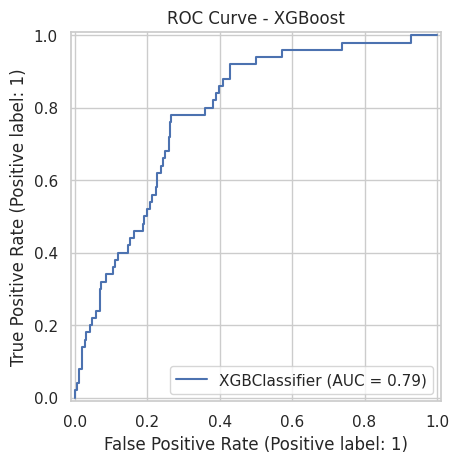

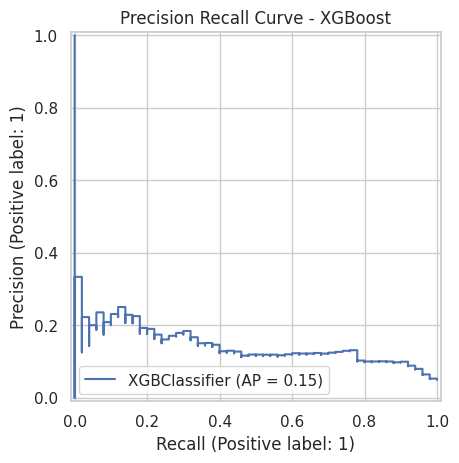

CatBoost
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       972
           1       0.19      0.12      0.15        50

    accuracy                           0.93      1022
   macro avg       0.57      0.55      0.56      1022
weighted avg       0.92      0.93      0.92      1022



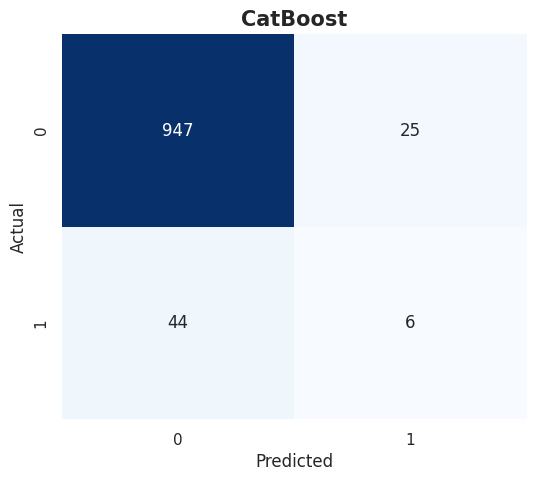

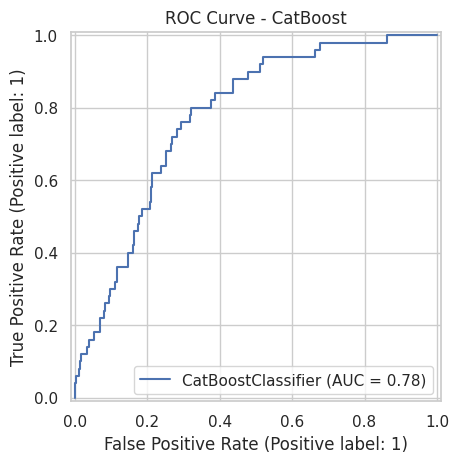

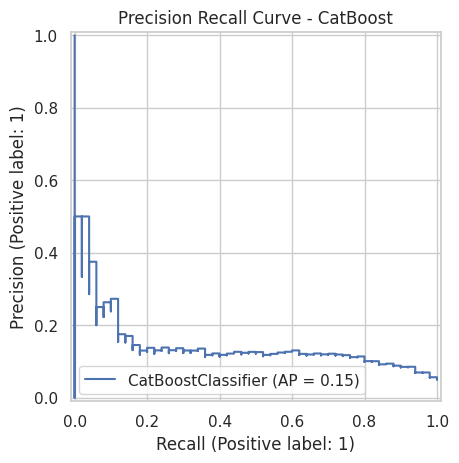

In [ ]:
trained_models = {}

trained_models["Logistic Regression"] = model_evaluate(
    LogisticRegression(max_iter=1000),
    "Logistic Regression"
)

trained_models["KNN"] = model_evaluate(
    KNeighborsClassifier(),
    "KNN"
)

trained_models["SVM"] = model_evaluate(
    SVC(),
    "SVM"
)

trained_models["Naive Bayes"] = model_evaluate(
    GaussianNB(),
    "Naive Bayes"
)

trained_models["Decision Tree"] = model_evaluate(
    DecisionTreeClassifier(random_state=42),
    "Decision Tree"
)

trained_models["Random Forest"] = model_evaluate(
    RandomForestClassifier(random_state=42),
    "Random Forest"
)

trained_models["Extra Trees"] = model_evaluate(
    ExtraTreesClassifier(random_state=42),
    "Extra Trees"
)

trained_models["Gradient Boosting"] = model_evaluate(
    GradientBoostingClassifier(random_state=42),
    "Gradient Boosting"
)

trained_models["AdaBoost"] = model_evaluate(
    AdaBoostClassifier(random_state=42),
    "AdaBoost"
)

trained_models["Bagging"] = model_evaluate(
    BaggingClassifier(random_state=42),
    "Bagging"
)

trained_models["LightGBM"] = model_evaluate(
    LGBMClassifier(random_state=42),
    "LightGBM"
)

trained_models["XGBoost"] = model_evaluate(
    XGBClassifier(random_state=42, eval_metric="logloss"),
    "XGBoost"
)

trained_models["CatBoost"] = model_evaluate(
    CatBoostClassifier(verbose=0, random_state=42),
    "CatBoost"
)

In [ ]:
best_model = trained_models[best_model_name]

In [ ]:
results_df = pd.DataFrame(results)
results_df = (
    results_df
    .sort_values(
        by=["Accuracy", "F1 Score"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(results_df)

# حفظ أفضل موديل
best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]

print("="*60)
print("Best Model :", best_model_name)
print("Accuracy   :", round(results_df.loc[0, "Accuracy"],4))
print("F1 Score   :", round(results_df.loc[0, "F1 Score"],4))
print("ROC AUC    :", round(results_df.loc[0, "ROC AUC"],4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,LightGBM,0.938356,0.275862,0.16,0.202532,0.801749
1,XGBoost,0.936399,0.222222,0.12,0.155844,0.785288
2,CatBoost,0.932485,0.193548,0.12,0.148148,0.775185
3,Random Forest,0.920744,0.170213,0.16,0.164948,0.755782
4,Extra Trees,0.917808,0.145833,0.14,0.142857,0.739290
5,Bagging,0.906067,0.140625,0.18,0.157895,0.743858
6,Decision Tree,0.874755,0.093750,0.18,0.123288,0.545247
7,Gradient Boosting,0.857143,0.152174,0.42,0.223404,0.794239
8,KNN,0.818982,0.114286,0.40,0.177778,0.687397
9,SVM,0.814090,0.131579,0.50,0.208333,0.779383


Best Model : LightGBM
Accuracy   : 0.9384
F1 Score   : 0.2025
ROC AUC    : 0.8017


In [ ]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: LightGBM


In [ ]:
from lightgbm import LGBMClassifier

best_model = LGBMClassifier(random_state=42)

In [ ]:
print(best_model_name)

LightGBM


In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# تدريب LightGBM للحصول على Feature Importance
fs_model = LGBMClassifier(random_state=42)
fs_model.fit(X_train_smote, y_train_smote)

importance = pd.Series(
    fs_model.feature_importances_,
    index=X_train_smote.columns
).sort_values(ascending=False)

feature_results = []

feature_numbers = [5, 10, 15, 20, len(X_train_smote.columns)]

for n in feature_numbers:

    selected_features = importance.head(n).index

    X_train_fs = X_train_smote[selected_features]
    X_test_fs = X_test_scaled[selected_features]

    model = LGBMClassifier(random_state=42)
    model.fit(X_train_fs, y_train_smote)

    pred = model.predict(X_test_fs)
    prob = model.predict_proba(X_test_fs)[:, 1]

    feature_results.append({
        "Top Features": n,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC AUC": roc_auc_score(y_test, prob)
    })

feature_results = (
    pd.DataFrame(feature_results)
    .sort_values(["Accuracy", "F1 Score"], ascending=False)
    .reset_index(drop=True)
)

display(feature_results)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3889, number of negative: 3889
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001253 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2158
[LightGBM] [Info] Number of data points in the train set: 7778, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 3889, number of negative: 3889
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000984 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 7778, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> init

,Top Features,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,15,0.940313,0.310345,0.18,0.227848,0.795185
1,20,0.940313,0.310345,0.18,0.227848,0.795185
2,16,0.940313,0.310345,0.18,0.227848,0.795185
3,5,0.934442,0.185185,0.10,0.129870,0.805597
4,10,0.933464,0.235294,0.16,0.190476,0.787778


In [ ]:
print(type(X_train))
print(type(X_train_smote))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [ ]:
best_n = feature_results.loc[0, "Top Features"]

selected_features = importance.head(best_n).index.tolist()

X_train_smote = X_train_smote[selected_features]
X_test_scaled = X_test_scaled[selected_features]

print("Best Number of Features:", best_n)
print(selected_features)

Best Number of Features: 15
['age', 'avg_glucose_level', 'bmi', 'gender_Male', 'work_type_Private', 'Residence_type', 'ever_married', 'smoking_status_never smoked', 'hypertension', 'smoking_status_smokes', 'smoking_status_formerly smoked', 'work_type_Self-employed', 'heart_disease', 'work_type_children', 'gender_Other']


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3889, number of negative: 3889
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002733 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2158
[LightGBM] [Info] Number of data points in the train set: 7778, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM Top 15 Features
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       972
           1       0.31      0.18      0.23        50

    accuracy                           0.94      1022
   macro avg       0.63      0.58      0.60      1022
weighted avg       0.93      0.94      0.93      1022



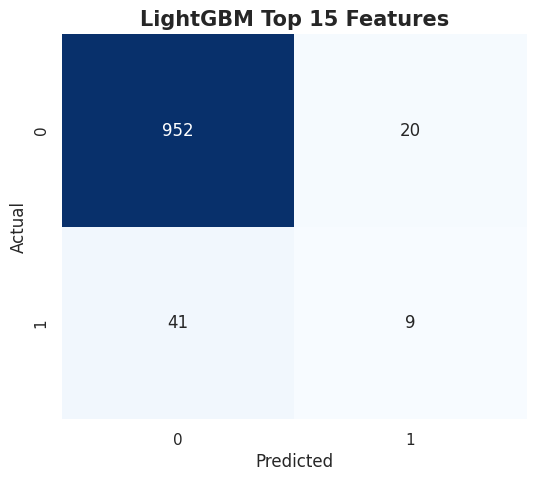

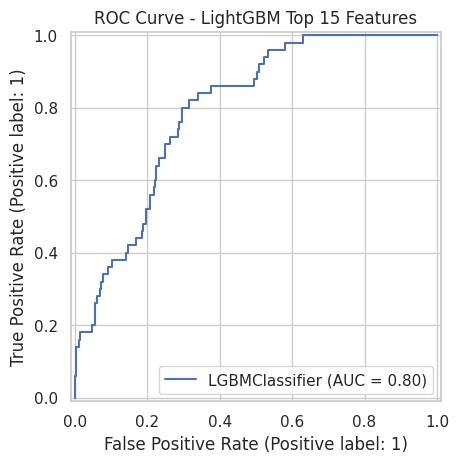

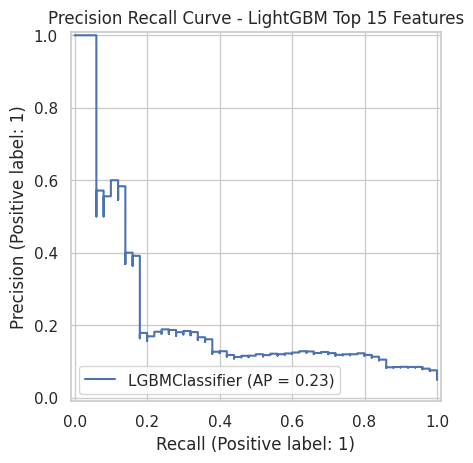

LGBMClassifier(random_state=42)

In [ ]:
best_model = LGBMClassifier(random_state=42)

model_evaluate(best_model, f"LightGBM Top {best_n} Features")

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV

# إنشاء الموديل
lgbm = LGBMClassifier(random_state=42)

# القيم التي سيتم تجربتها
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [5, 7],
    "num_leaves": [31, 50]
}

grid = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    scoring="accuracy",      # أو "f1" لو حابب تعتمد عليه
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_smote, y_train_smote)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3889, number of negative: 3889
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001657 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2158
[LightGBM] [Info] Number of data points in the train set: 7778, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

GridSearchCV(cv=5, estimator=LGBMClassifier(random_state=42), n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [5, 7],
                         'n_estimators': [100, 200], 'num_leaves': [31, 50]},
             scoring='accuracy', verbose=2)

In [ ]:
print("Best Parameters:")
print(grid.best_params_)

print("Best CV Accuracy:")
print(grid.best_score_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'num_leaves': 50}
Best CV Accuracy:
0.9614336372428273


In [ ]:
best_model = grid.best_estimator_

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3889, number of negative: 3889
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000927 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2158
[LightGBM] [Info] Number of data points in the train set: 7778, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with p

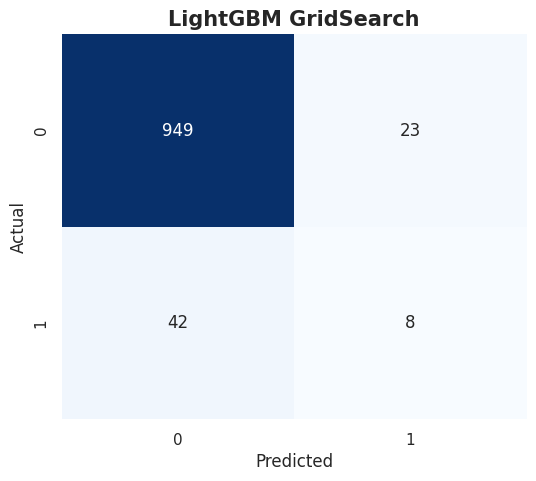

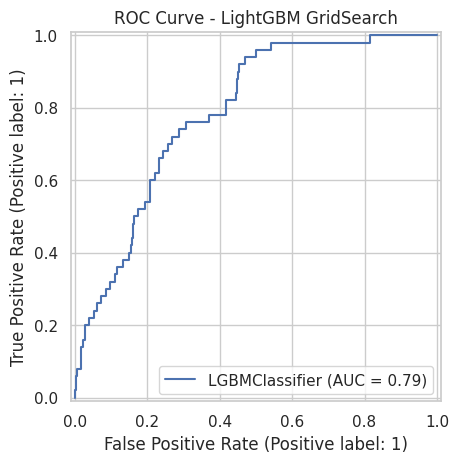

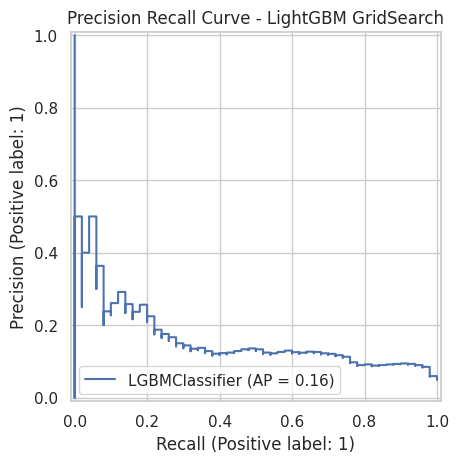

LGBMClassifier(max_depth=7, n_estimators=200, num_leaves=50, random_state=42)

In [ ]:
model_evaluate(best_model, "LightGBM GridSearch")

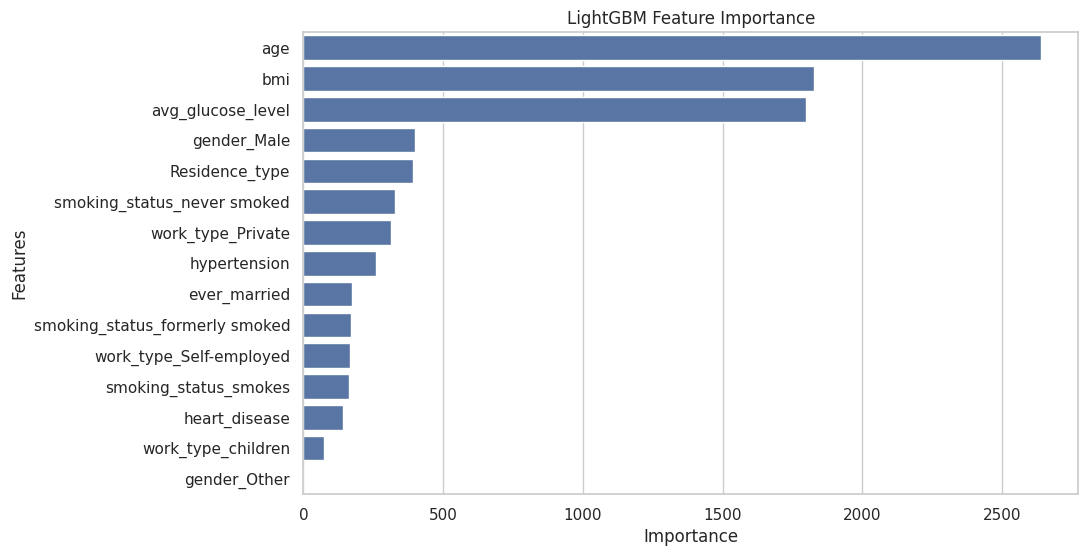

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

importance = pd.Series(
    best_model.feature_importances_,
    index=X_train_smote.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(
    x=importance.values,
    y=importance.index
)
plt.title("LightGBM Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [ ]:
selected_features = importance.head(5).index.tolist()

print(selected_features)

['age', 'bmi', 'avg_glucose_level', 'gender_Male', 'Residence_type']


In [ ]:
print(X_train_smote.columns.tolist())

['age', 'avg_glucose_level', 'bmi', 'gender_Male', 'work_type_Private', 'Residence_type', 'ever_married', 'smoking_status_never smoked', 'hypertension', 'smoking_status_smokes', 'smoking_status_formerly smoked', 'work_type_Self-employed', 'heart_disease', 'work_type_children', 'gender_Other']


In [ ]:
print(type(best_scaler))

<class 'sklearn.preprocessing._data.StandardScaler'>


In [ ]:
selected_features = ['age', 'bmi', 'avg_glucose_level', 'gender_Male', 'Residence_type']

X_train_5 = X_train_smote[selected_features]
X_test_5 = X_test_scaled[selected_features]

best_model = LGBMClassifier(**grid.best_params_, random_state=42)
best_model.fit(X_train_5, y_train_smote)

[LightGBM] [Info] Number of positive: 3889, number of negative: 3889
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000572 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 7778, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

LGBMClassifier(max_depth=7, n_estimators=200, num_leaves=50, random_state=42)

In [ ]:
pred = best_model.predict(X_test_5)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9461839530332681


In [ ]:
from sklearn.preprocessing import StandardScaler

selected_features = ['age', 'bmi', 'avg_glucose_level', 'gender_Male', 'Residence_type']

scaler_5 = StandardScaler()

X_train_5 = pd.DataFrame(
    scaler_5.fit_transform(X_train_5),
    columns=selected_features
)

X_test_5 = pd.DataFrame(
    scaler_5.transform(X_test_5),
    columns=selected_features
)

best_model.fit(X_train_5, y_train_smote)

[LightGBM] [Info] Number of positive: 3889, number of negative: 3889
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000671 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 7778, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

LGBMClassifier(max_depth=7, n_estimators=200, num_leaves=50, random_state=42)

In [ ]:
import joblib

joblib.dump(best_model, "lightgbm_stroke_model.pkl")
joblib.dump(scaler_5, "scaler_5.pkl")

['scaler_5.pkl']

In [ ]:
import gradio as gr
import pandas as pd

def predict(age, bmi, glucose, gender, residence):

    gender_male = 1 if gender == "Male" else 0
    residence_type = 1 if residence == "Urban" else 0

    data = pd.DataFrame({
        "age": [age],
        "bmi": [bmi],
        "avg_glucose_level": [glucose],
        "gender_Male": [gender_male],
        "Residence_type": [residence_type]
    })

    # نفس الـ Scaling المستخدم أثناء التدريب
    data = pd.DataFrame(
        scaler_5.transform(data),
        columns=selected_features
    )

    prediction = best_model.predict(data)[0]
    probability = best_model.predict_proba(data)[0][1]

    result = (
        "⚠️ High Risk of Stroke"
        if prediction == 1
        else "✅ Low Risk of Stroke"
    )

    return result, f"{probability*100:.2f}%"

demo = gr.Interface(
    fn=predict,
    inputs=[
        gr.Slider(1, 100, value=50, label="Age"),
        gr.Number(label="BMI"),
        gr.Number(label="Average Glucose Level"),
        gr.Radio(["Male", "Female"], label="Gender"),
        gr.Radio(["Urban", "Rural"], label="Residence Type")
    ],
    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Textbox(label="Stroke Probability")
    ],
    title="🩺 Stroke Prediction System",
    description="Predict stroke risk using the top 5 features selected by LightGBM."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2a6bac2cf57b02cdd9.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
